# SO(n): train VP-SDE score net

Saves a checkpoint that `02_train_jacnet.ipynb` and `03_fr_guidance.ipynb` both load.

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

config = {
    "n": int(os.environ.get("SO_N", 5)),
    "N_data": int(os.environ.get("N_DATA", 100)),
    "beta_min": 0.1, "beta_max": 20.0, "T": 1.0,
    "hidden": 256, "depth": 4, "batch": 512, "lr": 2e-4,
    "iters": 500000, "n_steps": 100, #for so2 50000 iters
    "seed": 0,
    "device": os.environ.get("DEVICE", "cpu"),
}
config["d"] = config["n"] ** 2
torch.manual_seed(config["seed"])
n, d, device = config["n"], config["d"], config["device"]
CKPT_DIR = f"checkpoints/n{n}_N{config['N_data']}"   # one folder per (n, N_data) -- 02_train_jacnet.ipynb
                                                      # and 03_fr_guidance.ipynb read from the same folder
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"n={n}, d={d}, N_data={config['N_data']}, device={device}, ckpt_dir={CKPT_DIR}")

n=5, d=25, N_data=100, device=cpu, ckpt_dir=checkpoints/n5_N100


In [2]:
def sample_haar(k, B):
    Z = torch.randn(B, k, k)
    Q, R = torch.linalg.qr(Z)
    signs = R.diagonal(dim1=-2, dim2=-1).sign()
    Q = Q * signs[:, None, :]
    Q[:, :, -1] *= torch.linalg.det(Q)[:, None]
    return Q

X_target = sample_haar(n, config["N_data"]).reshape(config["N_data"], d).to(device)
det_check = torch.linalg.det(X_target.reshape(-1, n, n))
print(f"X_target: {X_target.shape}  det range: [{det_check.min():.4f}, {det_check.max():.4f}]")

X_target: torch.Size([100, 25])  det range: [1.0000, 1.0000]


In [3]:
def beta(t):
    return config["beta_min"] + t * (config["beta_max"] - config["beta_min"])

def alpha_bar(t):
    return torch.exp(-(config["beta_min"] * t + 0.5 * (config["beta_max"] - config["beta_min"]) * t ** 2))

def q_sample(x0, t):
    eps = torch.randn_like(x0)
    a = alpha_bar(t)[:, None]
    return a.sqrt() * x0 + (1 - a).sqrt() * eps, eps

In [4]:
class ScoreNet(nn.Module):
    def __init__(self, d, hidden, depth):
        super().__init__()
        self.input_proj = nn.Linear(d + 1, hidden)
        self.layers = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(depth * 2)])
        self.output_proj = nn.Linear(hidden, d)

    def forward(self, x, t):
        h = F.silu(self.input_proj(torch.cat([x, t[:, None]], dim=-1)))
        for i in range(0, len(self.layers), 2):
            r = F.silu(self.layers[i](h))
            r = self.layers[i + 1](r)
            h = h + r
        return self.output_proj(h)

net = ScoreNet(d, config["hidden"], config["depth"]).to(device)
print(f"Parameters: {sum(p.numel() for p in net.parameters()):,}")

def loss_fn(net, x0):
    t = torch.rand(x0.shape[0], device=x0.device).clamp(min=1e-3) * config["T"]
    xt, eps = q_sample(x0, t)
    return ((net(xt, t) - eps) ** 2).mean()

Parameters: 539,673


iter      0  loss=1.0266
iter  25000  loss=0.0529
iter  50000  loss=0.0474
iter  75000  loss=0.0459
iter 100000  loss=0.0468
iter 125000  loss=0.0425
iter 150000  loss=0.0417
iter 175000  loss=0.0384
iter 200000  loss=0.0438
iter 225000  loss=0.0379
iter 250000  loss=0.0365
iter 275000  loss=0.0366
iter 300000  loss=0.0470
iter 325000  loss=0.0401
iter 350000  loss=0.0374
iter 375000  loss=0.0357
iter 400000  loss=0.0379
iter 425000  loss=0.0354
iter 450000  loss=0.0372
iter 475000  loss=0.0416
Training done.


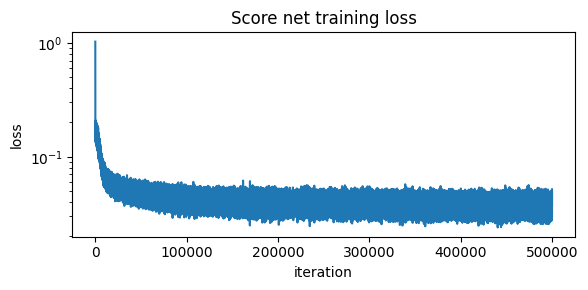

In [5]:
opt = torch.optim.Adam(net.parameters(), lr=config["lr"])
losses = []
print_every = max(1, config["iters"] // 20)
for i in range(config["iters"]):
    idx = torch.randint(0, config["N_data"], (config["batch"],))
    loss = loss_fn(net, X_target[idx])
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    if i % print_every == 0:
        print(f"iter {i:6d}  loss={loss.item():.4f}")
net.eval()
print("Training done.")

plt.figure(figsize=(6, 3))
plt.semilogy(losses)
plt.xlabel("iteration"); plt.ylabel("loss"); plt.title("Score net training loss")
plt.tight_layout(); plt.show()

## Sanity check: unguided samples, orthogonality residual, memorization signal

Same diagnostics style as `so_n_diffusion.ipynb`'s eval plan: orthogonality residual `||M M^T - I||_F` and
determinant, both via the plain reverse SDE sampler (no projection, no guidance).

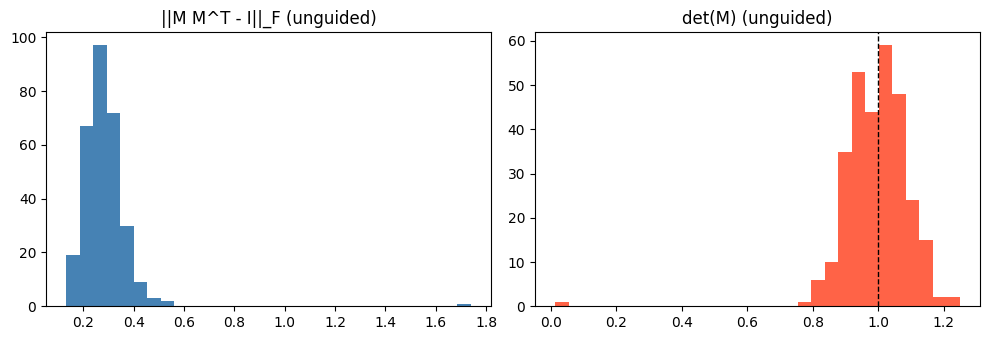

mean orth_resid=0.2853  mean det=0.9958


In [6]:
def sample(B, n_steps=None):
    n_steps = n_steps or config["n_steps"]
    x = torch.randn(B, d, device=device)
    dt = config["T"] / n_steps
    for k in reversed(range(n_steps)):
        t = torch.full((B,), (k + 1) * dt, device=device)
        eps_hat = net(x, t)
        score = -eps_hat / (1 - alpha_bar(t))[:, None].sqrt()
        drift = -0.5 * beta(t)[:, None] * x - beta(t)[:, None] * score
        noise = beta(t)[:, None].sqrt() * torch.randn_like(x) if k > 0 else 0
        x = x - drift * dt + noise * dt ** 0.5
    return x.detach()

with torch.no_grad():
    X_gen = sample(300)
M_gen = X_gen.reshape(-1, n, n)
orth_resid = (torch.bmm(M_gen, M_gen.transpose(-1, -2)) - torch.eye(n, device=device)).norm(dim=(-2, -1))
det_gen = torch.linalg.det(M_gen)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(orth_resid.cpu().numpy(), bins=30, color="steelblue")
axes[0].set_title("||M M^T - I||_F (unguided)")
axes[1].hist(det_gen.cpu().numpy(), bins=30, color="tomato")
axes[1].axvline(1.0, color="black", ls="--", lw=1)
axes[1].set_title("det(M) (unguided)")
plt.tight_layout(); plt.show()
print(f"mean orth_resid={orth_resid.mean():.4f}  mean det={det_gen.mean():.4f}")

In [7]:
torch.save({
    "net_state": net.state_dict(),
    "X_target": X_target.cpu(),
    "config": config,
}, f"{CKPT_DIR}/score.pt")
print(f"Saved {CKPT_DIR}/score.pt")

Saved checkpoints/n5_N100/score.pt
